<a href="https://colab.research.google.com/github/ducpvgch240415-cpu/PollSurvey-backend/blob/main/London_Map.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

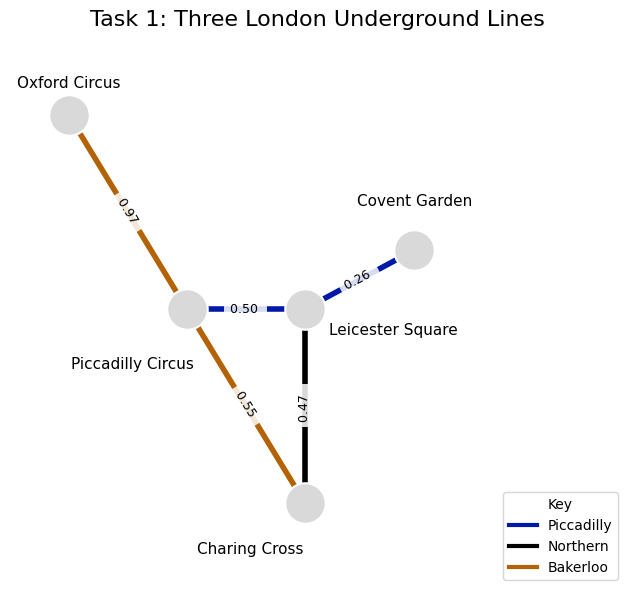

In [ ]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

edge_data = [
    ("Oxford Circus", "Piccadilly Circus", 0.97, "Bakerloo"),
    ("Piccadilly Circus", "Charing Cross", 0.55, "Bakerloo"),
    ("Charing Cross", "Leicester Square", 0.47, "Northern"),
    ("Piccadilly Circus", "Leicester Square", 0.50, "Piccadilly"),
    ("Leicester Square", "Covent Garden", 0.26, "Piccadilly"),
]

line_colours = {

    "Piccadilly": "#0019A8",
    "Northern": "#000000",
    "Bakerloo": "#B36305",

}

positions = {
    "Oxford Circus": (-2.0, 2.6),
    "Piccadilly Circus": (-0.6, 0.3),
    "Charing Cross": (0.8, -2.0),
    "Leicester Square": (0.8, 0.3),
    "Covent Garden": (2.1, 1.0),
}

graph = nx.Graph()
for station_a, station_b, distance, line in edge_data:
    graph.add_edge(station_a, station_b, distance=distance, line=line)

fig, ax = plt.subplots(figsize=(10, 7))
# line colours
for line, colour in line_colours.items():
    line_edges = [
        (station_a, station_b)
        for station_a, station_b, data in graph.edges(data=True)
        if data["line"] == line
    ]
    nx.draw_networkx_edges(
        graph,
        positions,
        edgelist=line_edges,
        edge_color=colour,
        width=4,
        ax=ax,
    )
    ax.plot([], [], color=colour, linewidth=3, label=line)

nx.draw_networkx_nodes(
    graph,
    positions,
    node_color="#D9D9D9",
    edgecolors="white",
    linewidths=1.5,
    node_size=850,
    ax=ax,
)

label_positions = {
    station: (x, y + 0.38) for station, (x, y) in positions.items()
}
label_positions["Piccadilly Circus"] = (-1.25, -0.35)
label_positions["Charing Cross"] = (0.15, -2.55)
label_positions["Leicester Square"] = (1.85, 0.05)
label_positions["Covent Garden"] = (2.1, 1.58)

nx.draw_networkx_labels(
    graph,
    label_positions,
    font_size=11,
    font_family="sans-serif",
    ax=ax,
)

distance_labels = {
    (station_a, station_b): f"{distance:.2f} "
    for station_a, station_b, distance, line in edge_data
}
nx.draw_networkx_edge_labels(
    graph,
    positions,
    edge_labels=distance_labels,
    font_size=9,
    rotate=True,
    bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.85},
    ax=ax,
)

ax.legend(title="Key", loc="lower right", frameon=True, fontsize=10)
ax.set_title("Task 1: Three London Underground Lines", fontsize=16, pad=16)
ax.set_axis_off()
ax.margins(0.15)
ax.set_aspect("equal")
ax.set_xlim(-2.7, 4.6)
ax.set_ylim(-3.0, 3.4)
plt.savefig("task1_map.png", dpi=300, bbox_inches="tight")
plt.show()

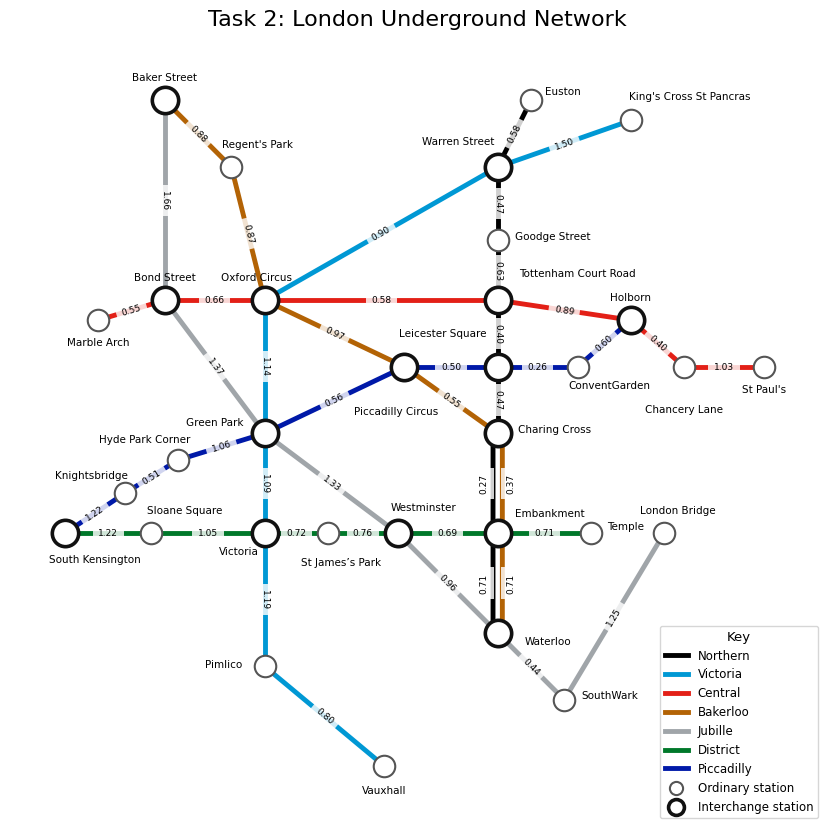

Number of lines: 7
Number of unique stations: 32
Number of line segments: 44
Number of ordinary stations: 17
Number of interchange stations: 15
Graph connected: True
Northern: 8 stations
Victoria: 7 stations
Central: 7 stations
Bakerloo: 7 stations
Jubille: 7 stations
District: 7 stations
Piccadilly: 8 stations


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# Underground line colours.
line_colours = {
    "Northern": "#000000",
    "Victoria": "#0098D4",
    "Central": "#E32017",
    "Bakerloo": "#B36305",
    "Jubille": "#A0A5A9",
    "District":"#00782A",
    "Piccadilly": "#0019A8",
}


# Station connections and distances in kilometres.
line_edges = {
    "Northern": [
        ("Euston", "Warren Street", 0.58),
        ("Warren Street", "Goodge Street", 0.47),
        ("Goodge Street", "Tottenham Court Road", 0.63),
        ("Tottenham Court Road", "Leicester Square", 0.40),
        ("Leicester Square", "Charing Cross", 0.47),
        ("Charing Cross", "Embankment", 0.27),
        ("Embankment", "Waterloo", 0.71),
    ],

    "Victoria": [
        # Euston is intentionally skipped: 0.74 + 0.76 = 1.50.
        ("King's Cross St Pancras", "Warren Street", 1.50),
        ("Warren Street", "Oxford Circus", 0.90),
        ("Oxford Circus", "Green Park", 1.14),
        ("Green Park", "Victoria", 1.09),
        ("Victoria", "Pimlico", 1.19),
        ("Pimlico", "Vauxhall", 0.80),
    ],

    "Central": [
        ("Marble Arch", "Bond Street", 0.55),
        ("Bond Street", "Oxford Circus", 0.66),
        ("Oxford Circus", "Tottenham Court Road", 0.58),
        ("Tottenham Court Road", "Holborn", 0.89),
        ("Holborn", "Chancery Lane", 0.40),
        ("Chancery Lane", "St Paul's", 1.03),
    ],

    "Bakerloo": [
        ("Baker Street", "Regent's Park", 0.88),
        ("Regent's Park", "Oxford Circus", 0.87),
        ("Oxford Circus", "Piccadilly Circus", 0.97),
        ("Piccadilly Circus", "Charing Cross", 0.55),
        ("Charing Cross", "Embankment", 0.37),
        ("Embankment", "Waterloo", 0.71),
    ],
    "Jubille": [
        ("Baker Street", "Bond Street", 1.66),
        ("Bond Street", "Green Park", 1.37),
        ("Green Park", "Westminster", 1.33),
        ("Westminster", "Waterloo", 0.96),
        ("Waterloo", "SouthWark", 0.44),
        ("SouthWark", "London Bridge", 1.25),
    ],
    "District":[
        ("Victoria", "Sloane Square", 1.05),
        ("Sloane Square", "South Kensington", 1.22),
        ("Victoria", "St James’s Park", 0.72),
        ("St James’s Park", "Westminster", 0.76),
        ("Westminster", "Embankment", 0.69),
        ("Embankment", "Temple", 0.71),

    ],
    "Piccadilly":[
        ("South Kensington", "Knightsbridge", 1.22),
        ("Knightsbridge", "Hyde Park Corner", 0.51),
        ("Hyde Park Corner", "Green Park", 1.06),
        ("Green Park", "Piccadilly Circus", 0.56),
        ("Piccadilly Circus", "Leicester Square", 0.50),
        ("Leicester Square", "ConventGarden", 0.26),
        ("ConventGarden", "Holborn", 0.60),
    ]

}


# Fixed station coordinates.
positions = {
    # Northern
    "Euston": (0.5, 3.0),
    "Warren Street": (0.0, 2.0),
    "Goodge Street": (0.0, 0.9),
    "Tottenham Court Road": (0.0, 0.0),
    "Leicester Square": (0.0, -1.0),
    "Charing Cross": (0.0, -2.0),
    "Embankment": (0.0, -3.5),
    "Waterloo": (0.0, -5.0),

    # Victoria
    "King's Cross St Pancras": (2, 2.7),
    "Oxford Circus": (-3.5, 0.0),
    "Green Park": (-3.5, -2.0),
    "Victoria": (-3.5, -3.5),
    "Pimlico": (-3.5, -5.5),
    "Vauxhall": (-1.7, -7.0),

    # Central
    "Marble Arch": (-6.0, -0.3),
    "Bond Street": (-5.0, 0.0),
    "Holborn": (2.0, -0.3),
    "Chancery Lane": (2.8, -1.0),
    "St Paul's": (4.0, -1.0),

    # Bakerloo
    "Baker Street": (-5.0, 3.0),
    "Regent's Park": (-4.0, 2.0),
    "Piccadilly Circus": (-1.4, -1.0),

    #Jubille
    "Westminster": (-1.5, -3.5),
    "SouthWark": (1, -6.0),
    "London Bridge": (2.5, -3.5),

    #District
    "St James’s Park": (-2.55, -3.5),
    "Sloane Square": (-5.2, -3.5),
    "South Kensington": (-6.5, -3.5),
    "Temple": (1.4, -3.5),
    #Pica
    "Knightsbridge": (-5.6, -2.9),
    "ConventGarden": (1.2, -1),
    "Hyde Park Corner": (-4.8, -2.4),
}


# Build graph.
graph = nx.Graph()

for line, edges in line_edges.items():
    for station_a, station_b, distance in edges:
        graph.add_edge(
            station_a,
            station_b,
            distance=distance,
        )


# Find which lines serve each station.
station_lines = {}

for line, edges in line_edges.items():
    for station_a, station_b, _ in edges:
        station_lines.setdefault(station_a, set()).add(line)
        station_lines.setdefault(station_b, set()).add(line)


ordinary_stations = [
    station
    for station, lines in station_lines.items()
    if len(lines) == 1
]

interchanges = [
    station
    for station, lines in station_lines.items()
    if len(lines) > 1
]


# parallel lines.
parallel_sections = [
    ("Charing Cross", "Embankment"),
    ("Embankment", "Waterloo"),
]


def is_parallel_section(station_a, station_b):
    """Check connections in either direction."""
    return any(
        {station_a, station_b} == {section_a, section_b}
        for section_a, section_b in parallel_sections
    )


def get_distance(line, station_a, station_b):
    """Read a distance automatically from line_edges."""
    for a, b, distance in line_edges[line]:
        if {a, b} == {station_a, station_b}:
            return distance

    raise ValueError(
        f"No connection found for {line}: "
        f"{station_a} to {station_b}"
    )


def draw_parallel_edge(
    ax,
    station_a,
    station_b,
    line,
    offset,
):
    """Draw an offset line that reconnects at both station centres."""
    x1, y1 = positions[station_a]
    x2, y2 = positions[station_b]

    dx = x2 - x1
    dy = y2 - y1
    length = (dx**2 + dy**2) ** 0.5

    if length == 0:
        raise ValueError(
            f"{station_a} and {station_b} have the same coordinates."
        )

    # Perpendicular offset.
    offset_x = (-dy / length) * offset
    offset_y = (dx / length) * offset

    # Enter and leave the parallel track near the station centres.
    start_x = x1 + (x2 - x1) * 0.10
    start_y = y1 + (y2 - y1) * 0.10

    end_x = x1 + (x2 - x1) * 0.90
    end_y = y1 + (y2 - y1) * 0.90

    ax.plot(
        [
            x1,
            start_x + offset_x,
            end_x + offset_x,
            x2,
        ],
        [
            y1,
            start_y + offset_y,
            end_y + offset_y,
            y2,
        ],
        color=line_colours[line],
        linewidth=3.5,
        solid_capstyle="round",
        solid_joinstyle="round",
        zorder=1,
    )

def draw_parallel_distance(
    ax,
    station_a,
    station_b,
    line,
    line_offset,
    label_gap=0.13,
):
    """Automatically display a parallel line's stored distance."""
    x1, y1 = positions[station_a]
    x2, y2 = positions[station_b]

    dx = x2 - x1
    dy = y2 - y1
    length = (dx**2 + dy**2) ** 0.5

    offset_direction = 1 if line_offset > 0 else -1
    label_offset = line_offset + offset_direction * label_gap

    offset_x = (-dy / length) * label_offset
    offset_y = (dx / length) * label_offset

    middle_x = (x1 + x2) / 2
    middle_y = (y1 + y2) / 2

    distance = get_distance(
        line,
        station_a,
        station_b,
    )

    rotation = (
        90
        if abs(dx) < 0.001
        else 0
    )

    ax.text(
        middle_x + offset_x,
        middle_y + offset_y,
        f"{distance:.2f}",
        fontsize=6.5,
        rotation=rotation,
        ha="center",
        va="center",
        bbox={
            "facecolor": "white",
            "edgecolor": "none",
            "alpha": 0.82,
        },
        zorder=4,
    )

# Create drawing area.
fig, ax = plt.subplots(figsize=(12, 8.2))

# normal connections.
for line, colour in line_colours.items():
    normal_edges = [
        (station_a, station_b)
        for station_a, station_b, _ in line_edges[line]
        if not (
            line in ("Northern", "Bakerloo")
            and is_parallel_section(station_a, station_b)
        )
    ]

    nx.draw_networkx_edges(
        graph,
        positions,
        edgelist=normal_edges,
        edge_color=colour,
        width=3.5,
        ax=ax,
    )
    # Creates the legend entry.
    ax.plot(
        [],
        [],
        color=colour,
        linewidth=3.5,
        label=line,
    )
# Parallel line positions:
# Bakerloo is on the left.
# Northern is on the right.
northern_offset = -0.07
bakerloo_offset = 0.07
# parallel lines.
for station_a, station_b in parallel_sections:
    draw_parallel_edge(

        ax, station_a, station_b, "Northern", northern_offset,
    )

    draw_parallel_edge(

        ax, station_a, station_b, "Bakerloo", bakerloo_offset,
    )

    # Distances are read automatically from line_edges.
    draw_parallel_distance(

        ax, station_a, station_b, "Northern", northern_offset,
    )

    draw_parallel_distance(

        ax, station_a, station_b, "Bakerloo", bakerloo_offset,
    )

# ordinary stations.
nx.draw_networkx_nodes(
    graph,
    positions,
    nodelist=ordinary_stations,
    node_color="white",
    edgecolors="#555555",
    linewidths=1.5,
    node_size=240,
    ax=ax,
)

# interchange stations.
nx.draw_networkx_nodes(
    graph,
    positions,
    nodelist=interchanges,
    node_color="white",
    edgecolors="#111111",
    linewidths=2.6,
    node_size=360,
    ax=ax,
)

# Station-label movements.
label_offsets = {
    "Hyde Park Corner": (-0.50, 0.30),
    "St James’s Park": (0.20, -0.44),
    "ConventGarden": (0.48, -0.28),
    "Knightsbridge": (-0.50, 0.26),
    "Temple": (0.52, 0.10),
    "South Kensington": (0.45, -0.40),
    "Sloane Square": (0.50, 0.34),
    "London Bridge": (0.20, 0.34),
    "SouthWark": (0.68, 0.06),
    "Westminster": (0.38, 0.38),

    "Euston": (0.48, 0.14),
    "Warren Street": (-0.60, 0.38),
    "Goodge Street": (0.82, 0.06),
    "Tottenham Court Road": (1.2, 0.40),
    "Leicester Square": (-0.82, 0.50),
    "Charing Cross": (0.85, 0.05),
    "Embankment": (0.78, 0.30),
    "Waterloo": (0.75, -0.12),

    "King's Cross St Pancras": (0.88, 0.36),
    "Oxford Circus": (-0.12, 0.34),
    "Green Park": (-0.75, 0.16),
    "Victoria": (-0.38, -0.28),
    "Pimlico": (-0.62, 0.02),
    "Vauxhall": (0.00, -0.36),

    "Marble Arch": (0.00, -0.34),
    "Bond Street": (0.00, 0.34),
    "Holborn": (0.00, 0.34),
    "Chancery Lane": (0.00, -0.64),
    "St Paul's": (0.00, -0.34),

    "Baker Street": (0.00, 0.34),
    "Regent's Park": (0.40, 0.34),
    "Piccadilly Circus": (-0.12, -0.68),
}

label_positions = {
    station: (
        x + label_offsets.get(station, (0.0, 0.0))[0],
        y + label_offsets.get(station, (0.0, 0.0))[1],
    )
    for station, (x, y) in positions.items()
}

nx.draw_networkx_labels(
    graph,
    label_positions,
    font_size=7.5,
    font_family="sans-serif",
    ax=ax,
)

# distance labels for all non-parallel connections.
for line, edges in line_edges.items():
    labels = {
        (station_a, station_b): f"{distance:.2f}"
        for station_a, station_b, distance in edges
        if not (
            line in ("Northern", "Bakerloo")
            and is_parallel_section(station_a, station_b)
        )
    }

    nx.draw_networkx_edge_labels(
        graph,
        positions,
        edge_labels=labels,
        font_size=6.5,
        rotate=True,
        bbox={
            "facecolor": "white",
            "edgecolor": "none",
            "alpha": 0.82,
        },
        ax=ax,
    )

# Ordinary station symbol
ax.scatter(
    [], [],
    s=90,
    facecolors="white",
    edgecolors="#555555",
    linewidths=1.5,
    label="Ordinary station",
)

# Interchange station symbol
ax.scatter(
    [], [],
    s=130,
    facecolors="white",
    edgecolors="#111111",
    linewidths=2.6,
    label="Interchange station",
)

# Legend and title.
ax.legend(
    title="Key",
    loc="lower right",
    frameon=True,
    fontsize=8.5,
    title_fontsize=9.5,
)

ax.set_title(
    "Task 2: London Underground Network", fontsize=16, pad=14,
)

# Coordinate grid automatically fitted around stations.
ax.set_axis_off()
ax.set_aspect("equal")
ax.margins(0.035)
plt.tight_layout(pad=0.2)

# Save and show map.
plt.savefig(
    "task2_map.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.03,
)

plt.show()

# Graph information.
print("Number of lines:", len(line_edges))
print("Number of unique stations:", graph.number_of_nodes())
print(
    "Number of line segments:",
    sum(len(edges) for edges in line_edges.values()),
)
print("Number of ordinary stations:", len(ordinary_stations))
print("Number of interchange stations:", len(interchanges))
print("Graph connected:", nx.is_connected(graph))

for line, edges in line_edges.items():
    stations = {
        station
        for station_a, station_b, _ in edges
        for station in (station_a, station_b)
    }
    print(f"{line}: {len(stations)} stations")

#calculations
distance_table = pd.DataFrame(
    [
        {
            "Line": line,
            "From": station_a,
            "To": station_b,
            "Distance (km)": distance,
        }
        for line, edges in line_edges.items()
        for station_a, station_b, distance in edges
    ]
)

distances_km = distance_table["Distance (km)"].to_numpy(dtype=float)

In [6]:
import numpy as np
import pandas as pd
# King's Cross St Pancras to Warren Street is a deliberate shortcut:
# 0.74 (King's Cross St Pancras–Euston) + 0.76 (Euston–Warren Street) = 1.50.
line_distances_km = {
    "Northern": [0.58, 0.47, 0.63, 0.40, 0.47, 0.27, 0.71],
    "Victoria": [1.50, 0.90, 1.14, 1.09, 1.19, 0.80],
    "Central": [0.55, 0.66, 0.58, 0.89, 0.40, 1.03],
    "Bakerloo": [0.88, 0.87, 0.97, 0.55, 0.37, 0.71],
    "Jubilee": [1.66, 1.37, 1.33, 0.96, 0.44, 1.25],
    "District": [1.05, 1.22, 0.72, 0.76, 0.69, 0.71],
    "Piccadilly": [1.22, 0.51, 1.06, 0.56, 0.50, 0.26, 0.60],
}
# pandas keeps the distances in a clear table; NumPy performs the calculations.
distance_table = pd.DataFrame(
    [
        {"Line": line, "Distance (km)": distance}
        for line, distances in line_distances_km.items()
        for distance in distances
    ]
)
distances_km = distance_table["Distance (km)"].to_numpy(dtype=float)

total_length = np.sum(distances_km)
average_distance = np.mean(distances_km)
standard_deviation = np.std(distances_km)

print(f"Number of station-to-station edges: {len(distances_km)}")
print(f"Total length of represented network: {total_length:.2f} km")
print(f"Average distance between adjacent stations: {average_distance:.2f} km")
print(f"Population standard deviation of distances: {standard_deviation:.2f} km")

print("\nDistance summary by line")
print(distance_table.groupby("Line")["Distance (km)"].agg(["count", "sum", "mean"]).round(2))

Number of station-to-station edges: 44
Total length of represented network: 35.48 km
Average distance between adjacent stations: 0.81 km
Population standard deviation of distances: 0.34 km

Distance summary by line
            count   sum  mean
Line                         
Bakerloo        6  4.35  0.72
Central         6  4.11  0.68
District        6  5.15  0.86
Jubilee         6  7.01  1.17
Northern        7  3.53  0.50
Piccadilly      7  4.71  0.67
Victoria        6  6.62  1.10
